# Feature Engineering and Modelling

## FeatureEngineering

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import matplotlib.dates as mdates

df_jun = pd.read_csv("clean_jun_v2.csv")

In [3]:
def engineer_ramp_features(df):
    df = df.copy()
    
    # 🌟 NEW: Ensure the index is DatetimeIndex
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'TIMESTAMP' in df.columns:
            df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
            df = df.set_index('TIMESTAMP').sort_index()
        else:
            raise TypeError("The dataframe must have a DatetimeIndex or a 'TIMESTAMP' column.")

    # A. Resample to 30-Minute Mean
    df_30 = df.resample('30T').mean()
    
    # B. Cyclical Temporal Features
    df_30['hour_sin'] = np.sin(2 * np.pi * df_30.index.hour / 24)
    df_30['hour_cos'] = np.cos(2 * np.pi * df_30.index.hour / 24)
    df_30['doy_sin']  = np.sin(2 * np.pi * df_30.index.dayofyear / 365.25)
    df_30['doy_cos']  = np.cos(2 * np.pi * df_30.index.dayofyear / 365.25)

    # C. Velocity & Acceleration (Ramp Mechanics)
    df_30['v_solar'] = df_30['solar_kw'].diff()
    df_30['a_solar'] = df_30['v_solar'].diff()
    df_30['solar_volatility_2h'] = df_30['solar_kw'].rolling(window=4).std()
    
    # D. Environmental Interaction
    if 'rh_avg' in df_30.columns:
        df_30['v_humidity'] = df_30['rh_avg'].diff()
        df_30['humidity_solar_risk'] = (df_30['rh_avg'] / 100) * (1 - df_30['solar_kw'])

    # E. SURGICAL MEMORY
    physical_sensors = ['solar_kw', 'net_rad_wm2', 'temp_c', 'rh_avg', 'wind_speed_ms', 'wind_dir', 'rain_mm']
    lag_cols = [c for c in physical_sensors if c in df_30.columns]

    for col in lag_cols:
        df_30[f'{col}_lag_6h'] = df_30[col].shift(12)
        df_30[f'{col}_lag_24h'] = df_30[col].shift(48)
        
    # F. 30m Step-by-Step History
    for i in range(1, 7): 
        df_30[f'solar_lag_{i*30}m'] = df_30['solar_kw'].shift(i)

    # G. Clear Sky Proxy & Wind Vectors
    df_30['solar_time_ratio'] = df_30['solar_kw'] / (df_30['hour_sin'] + 0.1)
    df_30['solar_time_ratio'] = df_30['solar_time_ratio'].clip(0, 5)
    
    wd_rad = np.radians(df_30['wind_dir'])
    df_30['wind_x'] = df_30['wind_speed_ms'] * np.cos(wd_rad)
    df_30['wind_y'] = df_30['wind_speed_ms'] * np.sin(wd_rad)

    if 'leaf_wetness' in df_30.columns:
        df_30['wet_ground_lag_6h'] = df_30['leaf_wetness'].shift(12)

    # True 1-hour trend (2 steps of 30 mins)
    df_30['solar_trend_1h'] = df_30['solar_kw'] - df_30['solar_kw'].shift(2)

    return df_30.dropna()

In [4]:
df_30 = engineer_ramp_features(df_jun)
df_30.columns

C:\Users\Salvador\AppData\Local\Temp\ipykernel_1424\3010083348.py:13: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_30 = df.resample('30T').mean()


Index(['rain_mm', 'temp_c', 'rh_avg', 'rh_max', 'rh_min', 'solar_kw',
       'net_rad_wm2', 'wind_speed_ms', 'wind_dir', 'soil_moisture_1',
       'soil_moisture_2', 'soil_moisture_3', 'leaf_wetness',
       'leaf_wet_minutes', 'rain_mm_is_missing', 'hour_sin', 'hour_cos',
       'doy_sin', 'doy_cos', 'v_solar', 'a_solar', 'solar_volatility_2h',
       'v_humidity', 'humidity_solar_risk', 'solar_kw_lag_6h',
       'solar_kw_lag_24h', 'net_rad_wm2_lag_6h', 'net_rad_wm2_lag_24h',
       'temp_c_lag_6h', 'temp_c_lag_24h', 'rh_avg_lag_6h', 'rh_avg_lag_24h',
       'wind_speed_ms_lag_6h', 'wind_speed_ms_lag_24h', 'wind_dir_lag_6h',
       'wind_dir_lag_24h', 'rain_mm_lag_6h', 'rain_mm_lag_24h',
       'solar_lag_30m', 'solar_lag_60m', 'solar_lag_90m', 'solar_lag_120m',
       'solar_lag_150m', 'solar_lag_180m', 'solar_time_ratio', 'wind_x',
       'wind_y', 'wet_ground_lag_6h', 'solar_trend_1h'],
      dtype='object')

In [5]:
df_30.to_csv("engineered_dataset.csv")

### Model Training

In [18]:
print("🧠 Training 6 Specialized Models for the 3-Hour Shift...")
df_ml = df_30.copy()

# ==========================================
# 1. TARGET GENERATION (30m to 180m)
# ==========================================
steps = list(range(1, 7)) 
solar_targets = [f'target_solar_diff_{s*30}m' for s in steps]

for s in steps:
    df_ml[f'target_solar_diff_{s*30}m'] = df_ml['solar_kw'].shift(-s) - df_ml['solar_kw']

# ==========================================
# 2. DAYLIGHT PRUNING (The "Junco" Filter)
# ==========================================
# We only train when the sun is up to focus model capacity on actual ramps.
df_final = df_ml[df_ml['solar_kw'] > 0.01].dropna()

print(f"Filtered out {len(df_ml) - len(df_final)} nighttime/edge rows.")
print(f"Training on {len(df_final)} high-value daylight samples.")

# --- DEFINE FEATURES ---
features = [c for c in df_final.columns if 'target' not in c]
print(f"Total Features for Training: {len(features)}")

# ==========================================
# 3. CHRONOLOGICAL SPLIT
# ==========================================
split_idx = int(len(df_final) * 0.8)
train, test = df_final.iloc[:split_idx], df_final.iloc[split_idx:]

# ==========================================
# 4. HYPERPARAMETERS & TRAINING
# ==========================================
xgb_params = {
    'objective': 'reg:pseudohubererror',
    'n_estimators': 350,
    'max_depth': 8,
    'learning_rate': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'random_state': 42,
    'n_jobs': -1
}

models_3h = {}
for i, t in enumerate(solar_targets):
    horizon_min = (i+1) * 30
    print(f"Training Model for T + {horizon_min}m...")
    m = xgb.XGBRegressor(**xgb_params)
    m.fit(train[features], train[t])
    models_3h[t] = m
    print(f"  ✅ Step {i+1} Ready.")

# ==========================================
# 5. ABSOLUTE ERROR EVALUATION (Watts)
# ==========================================
print("\n--- 📊 FINAL EVALUATION (Daytime Only) ---")

for t in solar_targets:
    # Get step number from string (e.g., 'target_solar_diff_30m' -> 30)
    minutes = int(t.split('_')[-1].replace('m',''))
    
    # 1. Predict the RAMP
    preds_ramp = models_3h[t].predict(test[features])
    
    # 2. Reconstruct ABSOLUTE (Current + Predicted Delta)
    preds_abs = np.clip(test['solar_kw'].values + preds_ramp, 0, None)
    
    # 3. Get the ACTUAL future value (Current + Actual Delta)
    actual_abs = test['solar_kw'].values + test[t].values
    
    # 4. Mask for High-Value Daylight
    mask = (~np.isnan(actual_abs)) & (actual_abs > 0.01)
    
    # Metrics
    mae_watts = mean_absolute_error(actual_abs[mask], preds_abs[mask]) * 1000
    error_abs = np.abs(actual_abs[mask] - preds_abs[mask])
    success_rate = (error_abs < 0.05).mean() * 100 
    
    print(f"Horizon +{minutes:3}m | MAE: {mae_watts:6.2f} W/m² | Within 50W: {success_rate:5.1f}%")

🧠 Training 6 Specialized Models for the 3-Hour Shift...
Filtered out 98783 nighttime/edge rows.
Training on 88832 high-value daylight samples.
Total Features for Training: 49
Training Model for T + 30m...
  ✅ Step 1 Ready.
Training Model for T + 60m...
  ✅ Step 2 Ready.
Training Model for T + 90m...
  ✅ Step 3 Ready.
Training Model for T + 120m...
  ✅ Step 4 Ready.
Training Model for T + 150m...
  ✅ Step 5 Ready.
Training Model for T + 180m...
  ✅ Step 6 Ready.

--- 📊 FINAL EVALUATION (Daytime Only) ---
Horizon + 30m | MAE:  32.23 W/m² | Within 50W:  79.8%
Horizon + 60m | MAE:  42.55 W/m² | Within 50W:  70.6%
Horizon + 90m | MAE:  49.25 W/m² | Within 50W:  64.7%
Horizon +120m | MAE:  54.60 W/m² | Within 50W:  60.8%
Horizon +150m | MAE:  58.86 W/m² | Within 50W:  57.2%
Horizon +180m | MAE:  61.91 W/m² | Within 50W:  55.3%


In [26]:
df_final['solar_kw'].describe()

count    88832.000000
mean         0.209681
std          0.163885
min          0.010045
25%          0.082079
50%          0.175000
75%          0.292500
max          1.007500
Name: solar_kw, dtype: float64

In [27]:
print("🎯 Training the 'Noon-Peak' Precision Engine (10:00 - 15:00)...")
df_ml = df_30.copy()

# ==========================================
# 1. TARGET GENERATION (30m to 180m)
# ==========================================
steps = list(range(1, 7)) 
solar_targets = [f'target_solar_diff_{s*30}m' for s in steps]

for s in steps:
    df_ml[f'target_solar_diff_{s*30}m'] = df_ml['solar_kw'].shift(-s) - df_ml['solar_kw']

# ==========================================
# 2. THE "DISPATCH WINDOW" FILTER
# ==========================================
# Filter for 10:00 to 15:00 (3 PM)
# This captures the high-irradiance, high-volatility window.
df_peak = df_ml[(df_ml.index.hour >= 10) & (df_ml.index.hour <= 15)].dropna()

print(f"Focused Training on {len(df_peak)} High-Variance Midday Samples.")

# --- DEFINE FEATURES ---
features = [c for c in df_peak.columns if 'target' not in c]

# ==========================================
# 3. CHRONOLOGICAL SPLIT & TRAIN
# ==========================================
split_idx = int(len(df_peak) * 0.8)
train, test = df_peak.iloc[:split_idx], df_peak.iloc[split_idx:]

xgb_params = {
    'objective': 'reg:pseudohubererror',
    'n_estimators': 400,    # Slightly more trees for the complex midday physics
    'max_depth': 9,         # Slightly deeper to catch micro-cloud interactions
    'learning_rate': 0.02,  # Even slower learning for precision
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'random_state': 42,
    'n_jobs': -1
}

models_peak = {}
for i, t in enumerate(solar_targets):
    print(f"Training Noon-Peak Model for T + {(i+1)*30}m...")
    m = xgb.XGBRegressor(**xgb_params)
    m.fit(train[features], train[t])
    models_peak[t] = m

# ==========================================
# 4. "STRESS TEST" EVALUATION (Midday Only)
# ==========================================
print("\n--- ⚡ MIDDAY STRESS TEST RESULTS ---")

for t in solar_targets:
    minutes = int(t.split('_')[-1].replace('m',''))
    preds_ramp = models_peak[t].predict(test[features])
    preds_abs = np.clip(test['solar_kw'].values + preds_ramp, 0, None)
    actual_abs = test['solar_kw'].values + test[t].values
    
    mae_watts = mean_absolute_error(actual_abs, preds_abs) * 1000
    error_abs = np.abs(actual_abs - preds_abs)
    success_rate = (error_abs < 0.05).mean() * 100 
    
    print(f"Peak Horizon +{minutes:3}m | MAE: {mae_watts:6.2f} W/m² | Within 50W: {success_rate:5.1f}%")

🎯 Training the 'Noon-Peak' Precision Engine (10:00 - 15:00)...
Focused Training on 46898 High-Variance Midday Samples.
Training Noon-Peak Model for T + 30m...
Training Noon-Peak Model for T + 60m...
Training Noon-Peak Model for T + 90m...
Training Noon-Peak Model for T + 120m...
Training Noon-Peak Model for T + 150m...
Training Noon-Peak Model for T + 180m...

--- ⚡ MIDDAY STRESS TEST RESULTS ---
Peak Horizon + 30m | MAE:  40.18 W/m² | Within 50W:  72.5%
Peak Horizon + 60m | MAE:  49.16 W/m² | Within 50W:  64.0%
Peak Horizon + 90m | MAE:  52.80 W/m² | Within 50W:  61.9%
Peak Horizon +120m | MAE:  51.45 W/m² | Within 50W:  63.4%
Peak Horizon +150m | MAE:  47.74 W/m² | Within 50W:  67.1%
Peak Horizon +180m | MAE:  43.21 W/m² | Within 50W:  70.3%


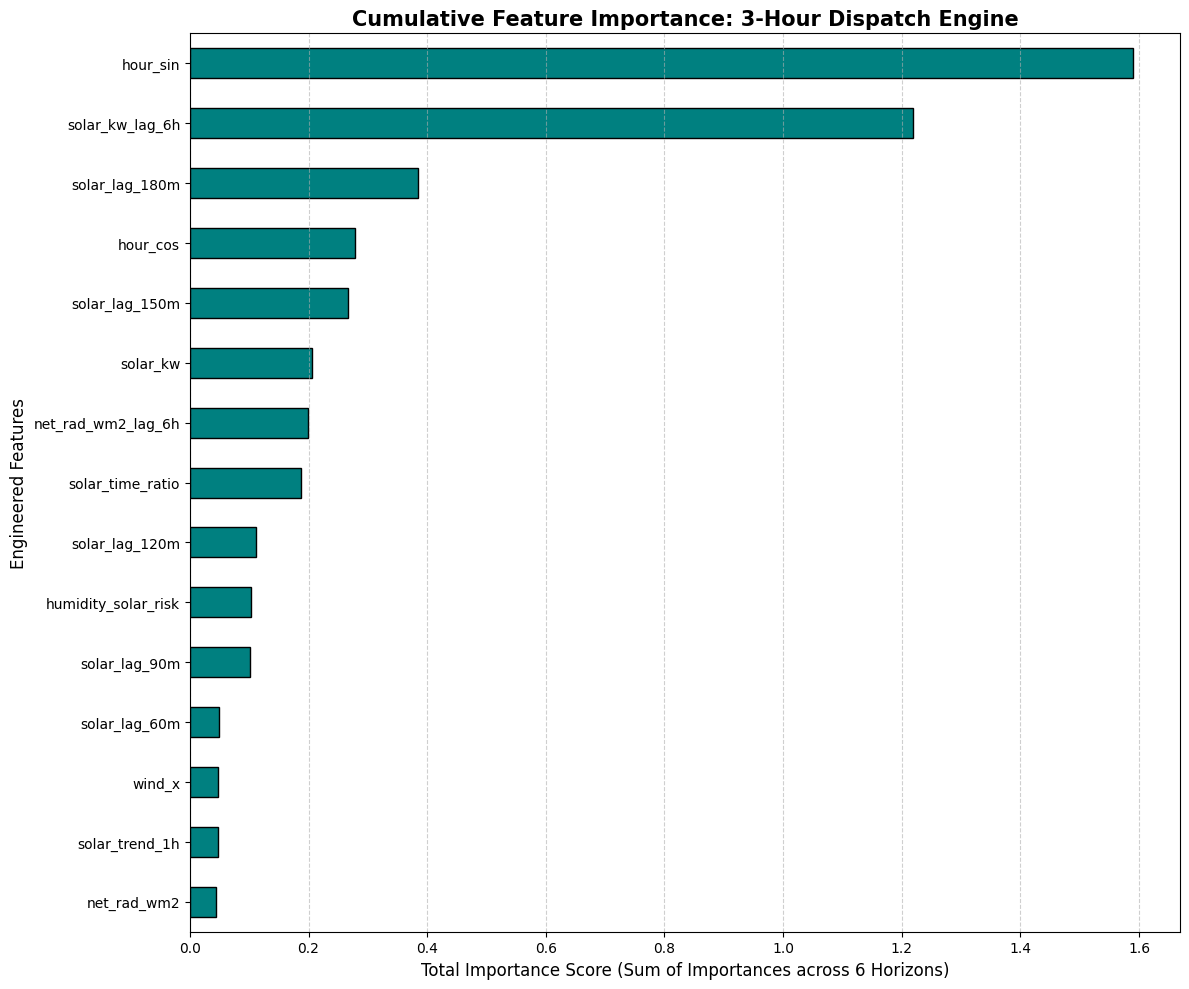

Top 10 Global Drivers for the 3-Hour Shift:
hour_sin               1.589553
solar_kw_lag_6h        1.219556
solar_lag_180m         0.385116
hour_cos               0.278328
solar_lag_150m         0.266100
solar_kw               0.206180
net_rad_wm2_lag_6h     0.199348
solar_time_ratio       0.187146
solar_lag_120m         0.111671
humidity_solar_risk    0.103818
dtype: float64


In [19]:
# ==========================================
# 6. AGGREGATE FEATURE IMPORTANCE
# ==========================================
# Initialize a Series with zeros for all features
total_importance = pd.Series(0, index=features)

# Accumulate importance from each of the 6 models
for target in solar_targets:
    total_importance += models_3h[target].feature_importances_

# Sort the results to find the top drivers
total_importance = total_importance.sort_values(ascending=False)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 10))

# Plotting the top 15 features for the pitch
total_importance.head(15).plot(kind='barh', color='teal', edgecolor='black')

plt.title("Cumulative Feature Importance: 3-Hour Dispatch Engine", fontsize=15, fontweight='bold')
plt.xlabel("Total Importance Score (Sum of Importances across 6 Horizons)", fontsize=12)
plt.ylabel("Engineered Features", fontsize=12)
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Top 10 Global Drivers for the 3-Hour Shift:")
print(total_importance.head(10))

C:\Users\Salvador\AppData\Local\Temp\ipykernel_1424\1212746431.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  target_time = pd.Timestamp(f"{target_date} {target_hour}:{target_minute}:00").floor('30T')


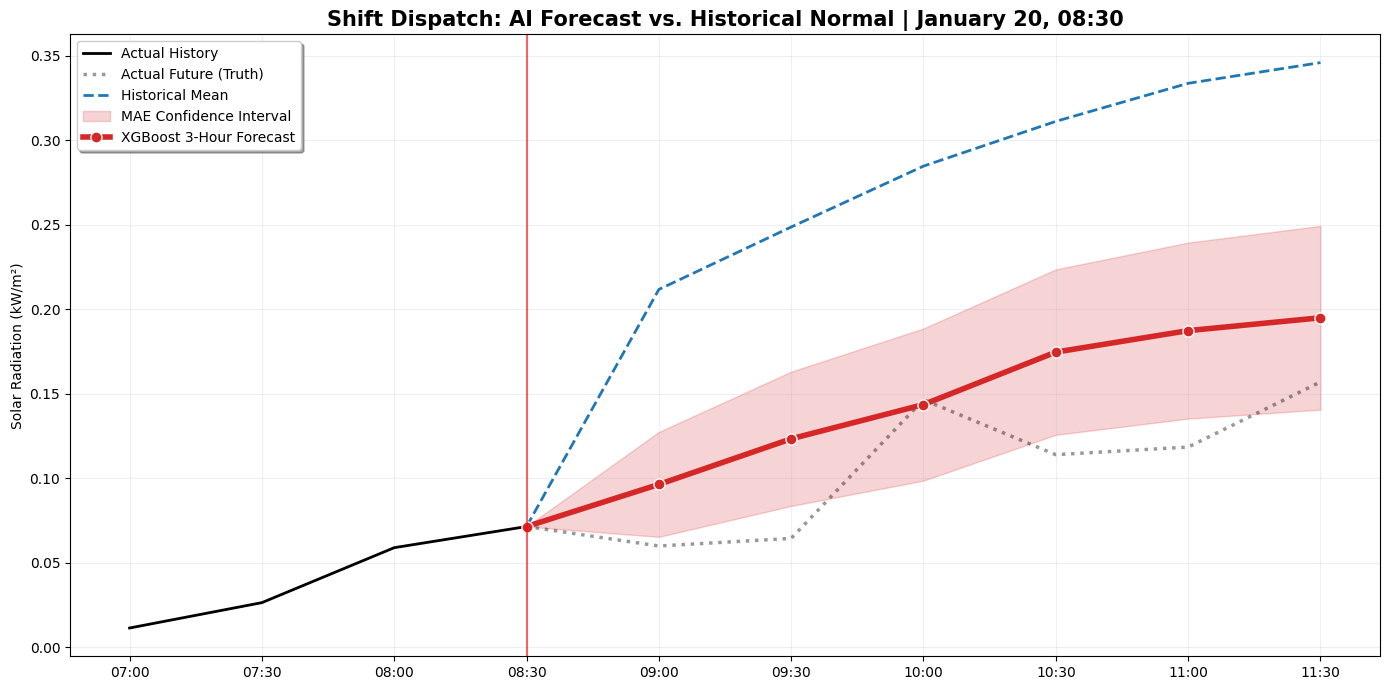

In [25]:
def plot_shift_forecast_with_intervals(target_date, target_hour, target_minute=0):
    # 1. Configuration: MAE values from your evaluation (converted W -> kW)
    mae_intervals = [0.03102, 0.03971, 0.04499, 0.04891, 0.05205, 0.05432]
    
    try:
        target_time = pd.Timestamp(f"{target_date} {target_hour}:{target_minute}:00").floor('30T')
    except Exception as e:
        print(f"Error: {e}")
        return

    if target_time not in test.index:
        print(f"⚠️ Timestamp {target_time} not found in test set.")
        return

    # 2. Prediction Generation
    current_features = test.loc[[target_time], features]
    current_val = test.loc[target_time, 'solar_kw']
    
    preds_abs = []
    for s in range(1, 7):
        t_key = f'target_solar_diff_{s*30}m'
        p_ramp = models_3h[t_key].predict(current_features)[0]
        preds_abs.append(np.clip(current_val + p_ramp, 0, None))
    
    # 3. Compute Bounds for the "Confidence Fan"
    # Origin (T+0) has 0 error; subsequent steps use your MAE data
    lower_bounds = [current_val] + [max(0, p - m) for p, m in zip(preds_abs, mae_intervals)]
    upper_bounds = [current_val] + [p + m for p, m in zip(preds_abs, mae_intervals)]
    
    # 4. Calculate Climatology (Historical Normal)
    climatology = train.groupby([train.index.hour, train.index.minute])['solar_kw'].mean()
    future_times = [target_time + pd.Timedelta(minutes=s*30) for s in range(1, 7)]
    y_mean_baseline = [current_val] + [climatology.get((t.hour, t.minute), 0) for t in future_times]
    
    # 5. Data Alignment
    history = test.loc[target_time - pd.Timedelta(hours=4) : target_time]
    actual_future = [test.loc[t, 'solar_kw'] if t in test.index else np.nan for t in future_times]
    plot_times = [target_time] + future_times
    y_preds = [current_val] + preds_abs
    y_actuals = [current_val] + actual_future

    # ==========================================
    # 🎨 THE PRESENTATION PLOT
    # ==========================================
    plt.figure(figsize=(14, 7))
    
    # Actual Data
    plt.plot(history.index, history['solar_kw'], color='black', linewidth=2, label='Actual History')
    plt.plot(plot_times, y_actuals, color='black', linestyle=':', linewidth=2.5, alpha=0.4, label='Actual Future (Truth)')
    
    # Historical Normal
    plt.plot(plot_times, y_mean_baseline, color='#1f77b4', linestyle='--', linewidth=2, label='Historical Mean')
    
    # XGBoost Forecast + Confidence Fan
    plt.fill_between(plot_times, lower_bounds, upper_bounds, color='#d62728', alpha=0.2, label='MAE Confidence Interval')
    plt.plot(plot_times, y_preds, color='#d62728', linewidth=4, marker='o', markersize=8, 
             label='XGBoost 3-Hour Forecast', markeredgecolor='white')
    
    # Visual Polish
    plt.axvline(target_time, color='red', alpha=0.6)
    plt.title(f"Shift Dispatch: AI Forecast vs. Historical Normal | {target_time.strftime('%B %d, %H:%M')}", fontsize=15, fontweight='bold')
    plt.ylabel("Solar Radiation (kW/m²)")
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.grid(True, alpha=0.2)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.tight_layout()
    plt.show()

# Run the test
plot_shift_forecast_with_intervals('2024-01-20', 8, 30)

In [16]:
def export_full_dashboard_feed(test_df, train_df, models, filename="full_dashboard_feed.csv"):
    df = test_df.copy()
    
    # 1. Horizon-Specific MAE (Confidence Intervals) from your evaluation
    # These represent the +/- 'buffer' the operator needs for each step
    mae_map = {
        '30m': 0.03102, '60m': 0.03971, '90m': 0.04499,
        '120m': 0.04891, '150m': 0.05205, '180m': 0.05432
    }
    
    # 2. Compute Climatology (The 'Historical Normal')
    climatology = train_df.groupby([train_df.index.hour, train_df.index.minute])['solar_kw'].mean()
    
    # 3. Generate Multi-Step Forecasts and Confidence Bounds
    # We loop through each horizon to create a full shift profile
    for horizon, mae in mae_map.items():
        target_key = f'target_solar_diff_{horizon}'
        
        # Predict the ramp and reconstruct the absolute kW
        preds_ramp = models[target_key].predict(df[features])
        df[f'fc_{horizon}'] = np.clip(df['solar_kw'] + preds_ramp, 0, None)
        
        # Compute the Confidence Interval (Prediction +/- MAE)
        df[f'low_{horizon}'] = np.clip(df[f'fc_{horizon}'] - mae, 0, None)
        df[f'high_{horizon}'] = df[f'fc_{horizon}'] + mae

    # 4. Add the Baselines and Operational Sensors
    df['hist_normal'] = df.index.map(lambda x: climatology.get((x.hour, x.minute)))
    
    # Define columns to export for the dashboard team
    export_cols = [
        'solar_kw', 'hist_normal',               # Truth & Baseline
        'solar_volatility_2h', 'solar_time_ratio', # Risk Sensors
        'solar_trend_1h'                         # Momentum
    ]
    # Add all forecast and interval columns
    for h in mae_map.keys():
        export_cols.extend([f'fc_{h}', f'low_{h}', f'high_{h}'])

    df[export_cols].to_csv(filename)
    print(f"✅ Full 3-Hour Dashboard Feed exported to {filename}")

# Execute export
export_full_dashboard_feed(test, train, models_3h)

✅ Full 3-Hour Dashboard Feed exported to full_dashboard_feed.csv
